In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame

In [2]:
df = pd.read_csv('categories.csv')
df.head()

,img_name,location,time_of_day,skyCondition,setting
0,a0001-jmac_DSC1459,outdoor,day,sun_sky,nature
1,a0002-dgw_005,indoor,day,mixed,people
2,a0003-NKIM_MG_8178,outdoor,day,sun_sky,man_made
3,a0004-jmac_MG_1384,outdoor,day,sun_sky,nature
4,a0005-jn_2007_05_10__564,outdoor,day,sun_sky,man_made


In [3]:
print(f"Total entries in the dataset: {df.shape[0]}")

Total entries in the dataset: 5000


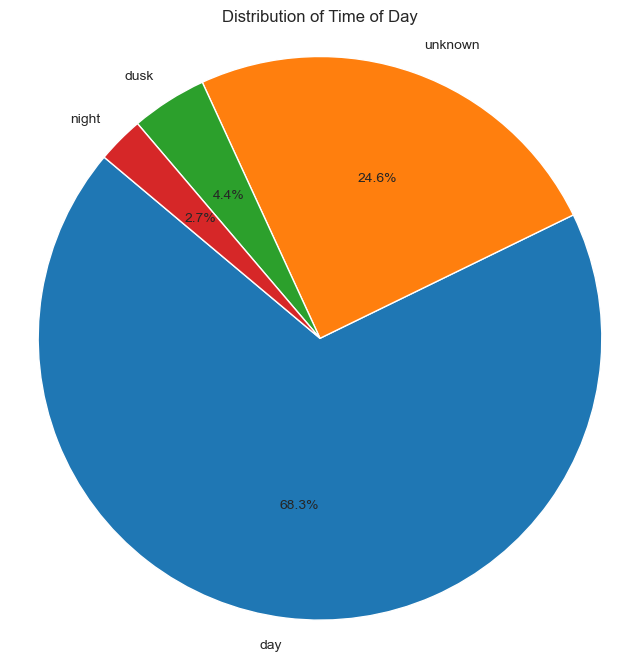

In [4]:
counts = df['time_of_day'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140) # Pie chart of time_of_day distribution
# setting_counts.index gives the names of the unique values in the 'time-of-day' column
plt.title('Distribution of Time of Day')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_6662/2282381609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='time_of_day', order=counts.index, palette='viridis')


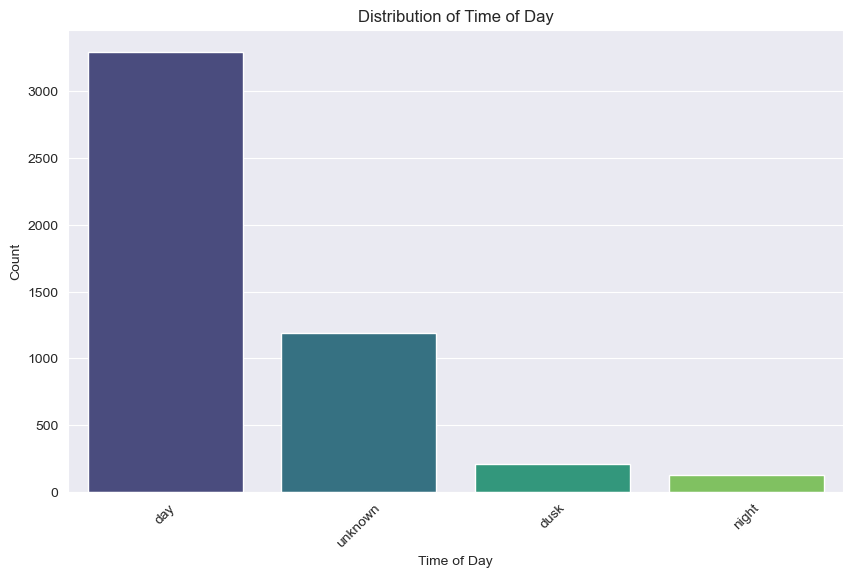

In [5]:
# Bar chart of time_of_day distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='time_of_day', order=counts.index, palette='viridis')
plt.title('Distribution of Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [6]:
count_of_unknown = df['time_of_day'] == 'unknown'
print(f"Count of 'unknown' entries in 'time_of_day': {count_of_unknown.sum()}")

Count of 'unknown' entries in 'time_of_day': 1188


Removing unknown entries from both the dataframe and the corresponding images from the folder

In [7]:
df.replace('unknown', np.nan, inplace=True)

In [9]:
#Removing files with unknown time_of_day
def remove_file(img_name:str):
    import os
    try:
        os.remove(f'raw_images_organised_time_of_day/{img_name}.jpg')
        print(f"Removed file: {img_name}")
    except FileNotFoundError:
        print(f"File not found: {img_name}")
    except Exception as e:
        print(f"Error removing file {img_name}: {e}")

time_of_day_unknown = df[df['time_of_day'].isna()]

print(time_of_day_unknown.columns)
time_of_day_unknown = df[df['time_of_day'].isna()]
time_of_day_unknown['img_name'].apply(lambda x: remove_file(x))

Index(['img_name', 'location', 'time_of_day', 'skyCondition', 'setting'], dtype='object')
File not found: a0008-WP_CRW_3959
File not found: a0019-jmac_MG_0653
File not found: a0022-IMG_2380
File not found: a0023-07-06-02-at-15h06m48-s_MG_1489
File not found: a0026-kme_391
File not found: a0047-07-11-18-at-00h05m40s-_MG_4882
File not found: a0049-_I2E5952
File not found: a0055-050729_194412__I2E5282
File not found: a0059-JI2E5556
File not found: a0061-jn_20080802_0003
File not found: a0063-IMG_4185
File not found: a0064-_DSC7889
File not found: a0066-Ja_Pe-65
File not found: a0073-IMG_2593
File not found: a0078-IMG_0326
File not found: a0080-kme_544
File not found: a0088-_DGW6376
File not found: a0096-_DGW6249
File not found: a0098-kme_187
File not found: a0102-IMG_3663-1
File not found: a0106-NKIM_120
File not found: a0108-kme_175
File not found: a0109-_DSC0022-1
File not found: a0112-kme_093
File not found: a0117-kme_006
File not found: a0125-kme_314
File not found: a0132-tc_DSC2376
F

7       None
18      None
21      None
22      None
25      None
        ... 
4986    None
4988    None
4991    None
4995    None
4996    None
Name: img_name, Length: 1367, dtype: object

In [548]:
#count of raw images remaining
import os
remaining_files = os.listdir('raw_images_organised_time_of_day')
print(f"Total remaining files in directory: {len(remaining_files)}")

Total remaining files in directory: 7298


In [549]:
df.dropna(inplace=True)

In [550]:
print(f"Total entries in the dataset: {df.shape[0]}")

Total entries in the dataset: 3519


In [551]:
df.to_csv('time_of_day_dataset.csv')

In [552]:
df_time_of_day = pd.read_csv('time_of_day_dataset.csv')

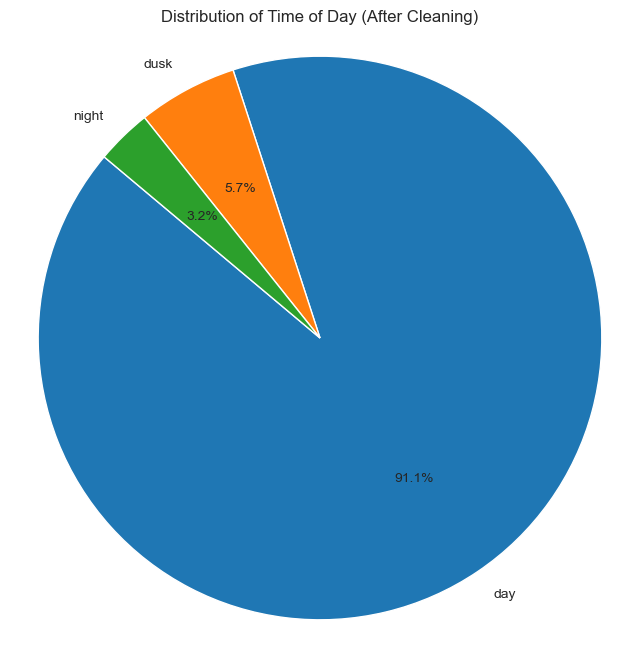

In [553]:
#Plot new distribution for new dataset pie chart
new_dataset_counts = df_time_of_day['time_of_day'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(new_dataset_counts, labels=new_dataset_counts.index, autopct='%1.1f%%', startangle=140) # Pie chart of time_of_day distribution
plt.title('Distribution of Time of Day (After Cleaning)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [554]:
#get all time_of_day day entries
day_entries = df_time_of_day[df_time_of_day['time_of_day'] == 'day']
print(f"Total entries in the dataset: {day_entries.shape[0]}")

Total entries in the dataset: 3206


load balanced dataset done via dataset_balancer.py

In [555]:
df_balanced = pd.read_csv('time-of-day-dataset_balanced.csv')

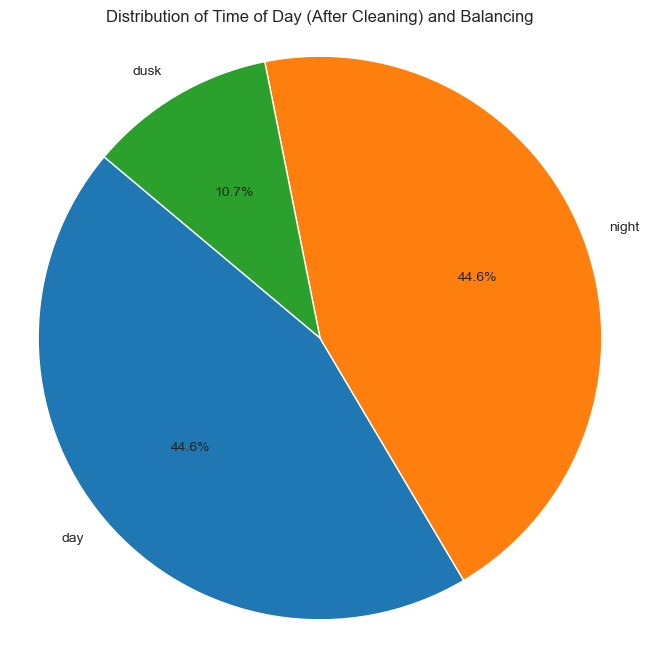

In [556]:
# Plot balanced dataset distribution pie chart
balanced_counts = df_balanced['time_of_day'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(balanced_counts, labels=balanced_counts.index, autopct='%1.1f%%', startangle=140) # Pie chart of time_of_day distribution
plt.title('Distribution of Time of Day (After Cleaning) and Balancing')
plt.axis('equal')
# Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
